In [12]:
# import packages 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [ ]:
# load and store the data into variable df 
df = pd.read_csv('netflix_titles.csv')
# display the data 
df 

# Inspecting the data 
# show how many rows and columns 
print("Number of rows and columns are: ", df.shape)
# show column names 
print("List of all columns: ")
df.columns.to_list()
# Show the index, data type and memory information 
print("Index, data type and memory of each column: ")
df.info()


In [ ]:
# Data cleaning 

# display missing/null values 
# print("The missing/null values are as follows:\n ", df.isnull())
# initial display of missing or null values is very noisy, 8807 rows is useless and unreadable to humans 

# display columns that have the most missing values 
print("The number of missing or null values are: \n", df.isnull().sum())

# From the output the following three columns had the most number of missing values 
# Director - 2634  
# Cast  - 825  
# Country - 831  
# This is because TV Shows and movies often have multiple directors and cast members 
# We will leave these as null for now and handle later 

# display duplicate data 
print("The count of duplicated values is: ",df.duplicated().sum())

In [70]:
# Exploring the data 
# How many Movies vs TV shows are in the dataset 
# count how many times each unique value appears in one column 
values = df["type"].value_counts()
print(values.index)


Index(['Movie', 'TV Show'], dtype='str', name='type')


In [ ]:
# Exploring the data 

# Display movies vs tv shows as a bar chart  ~ matplotlib 
values = df["type"].value_counts()
categories = values.index

bars = plt.bar(categories, values, color='skyblue', edgecolor='navy')
plt.bar_label(bars)

plt.xlabel('Type')
plt.ylabel('Count')
plt.title('Netflix library is Dominated by Movies at 70%')

plt.show()

In [ ]:
# Exploring the data 
# Display movies vs tv shows as a bar chart  ~ seaborn
total = df["type"].value_counts().reset_index()
ax = sns.barplot(data=total, x="type", y="count")
ax.bar_label(ax.containers[0])
plt.title("Netflix library is dominated by movies at 70%")
plt.show()

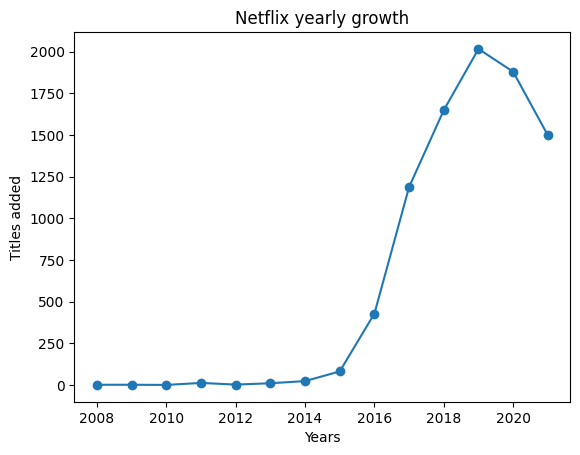

In [ ]:
# Year by Year Growth 
# How has Netflix content grown year by year 

#print(df['date_added'].head(10))

df['date_added'] = pd.to_datetime(df['date_added'], format='mixed')
#print(df['date_added'].dtype)

# changed the date_added column data type to that of datetime 
# adding a new column called year_added, getting the year from the column date_added

df['year_added'] = pd.DatetimeIndex(df['date_added']).year
# print(df['date_added'])

# Graph with matplotlib 
# Count how many titles were added per year 
titles = df['year_added'].value_counts()
# Sort the years in chronlogical order 
titles_sorted = titles.sort_index()

# Plot it as a line chart
plt.plot(titles_sorted.index, titles_sorted.values, marker='o')
plt.title("Netflix yearly growth")
plt.xlabel("Years")
plt.ylabel("Titles added")
plt.show()





In [ ]:
# Seaborn line graph 
total_years = titles_sorted.reset_index()
print(total_years)
ax1 = sns.lineplot(data=total_years, x='year_added', y='count')
ax1.set_xlabel("Years", fontsize=12)
ax1.set_ylabel("Titles added", fontsize=12)
# ax1.set(xlabel="Years", ylabel="Titles added", title="Netflix yearly growth")
plt.title("Netflix yearly growth")
plt.show()

The line graph shows Netflix having a steady and consistent growth from years 2015 with its peak being in the year 2019. 
The graph does not go beyon the year 2020, as the dataset used has titles add till mid 2021, limiting future comparison of growth for more recent years. 
The dip in the graph from 2019 is linked to the external factor of teh global pandemic COVID-19 which limited productions being made and uplaoded to the platform globally. 
In order to make a stronger conclusion and analysis of Netflix's growth more data is required from 2021-present(2026). This would allow us to compare the growth of Netflix post-pandemic and analyse its overall growth. 

In [106]:
# Which country produced the most content on Netflix 
country_total = df['country'].value_counts
print(country_total)

<bound method IndexOpsMixin.value_counts of 0       United States
1        South Africa
2                 NaN
3                 NaN
4               India
            ...      
8802    United States
8803              NaN
8804    United States
8805    United States
8806            India
Name: country, Length: 8807, dtype: str>
